1. Setup

In [1]:
!pip install -q torch torchvision tqdm

2. Imports & Device

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


3.A Upload the dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving UStar_Optical_Ranging_New_Simulated_Dataset.zip to UStar_Optical_Ranging_New_Simulated_Dataset.zip


3.B. Download from Google Drive (if the dataset is larger)



In [15]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/Colab Notebooks/Research/UStar/Datasets/New Training Datasets/UStar_Optical_Ranging_New_Real_Dataset.zip" "/content/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


4. Unzip the dataset and remove the zip file

In [5]:
# Unzip directly into a matching folder
!mkdir -p "/content/$UStar_Optical_Ranging_New_Simulated_Dataset"
!unzip -q "UStar_Optical_Ranging_New_Simulated_Dataset.zip" -d "UStar_Optical_Ranging_New_Simulated_Dataset"

# Remove ZIP
!rm "UStar_Optical_Ranging_New_Simulated_Dataset.zip"

5. Data Preparation

In [6]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ✅ Correct location of the dataset directory
data_dir = "/content/UStar_Optical_Ranging_New_Simulated_Dataset"

# ImageNet normalization
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
    "test": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]),
}

# Only include splits that actually exist
image_datasets = {}
for split in ["train", "val", "test"]:
    split_dir = os.path.join(data_dir, split)
    print("Looking for:", split_dir)
    if os.path.isdir(split_dir):
        image_datasets[split] = datasets.ImageFolder(split_dir, data_transforms[split])

print("Found splits:", list(image_datasets.keys()))

dataloaders = {
    split: DataLoader(
        image_datasets[split],
        batch_size=32,
        shuffle=(split == "train"),
        num_workers=2,
        pin_memory=True
    )
    for split in image_datasets.keys()
}

dataset_sizes = {split: len(image_datasets[split]) for split in image_datasets.keys()}

# ✅ This will now work because "train" exists
class_names = image_datasets["train"].classes

print("Classes:", class_names)
print("Dataset sizes:", dataset_sizes)

Looking for: /content/UStar_Optical_Ranging_New_Simulated_Dataset/train
Looking for: /content/UStar_Optical_Ranging_New_Simulated_Dataset/val
Looking for: /content/UStar_Optical_Ranging_New_Simulated_Dataset/test
Found splits: ['train', 'val', 'test']
Classes: ['1m', '2m', '3m', '4m']
Dataset sizes: {'train': 700, 'val': 200, 'test': 100}


6. Model — Pretrained ResNet-18 (Freeze Backbone, Train Only Classifier)


In [7]:
# ---- Load pretrained ResNet-18 (ImageNet) ----
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace final layer based on class numbers
num_ftrs = model.fc.in_features
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

# ---- Freeze all layers except fc + layer4 ----
for name, p in model.named_parameters():
    if name.startswith("fc.") or name.startswith("layer4."):
        p.requires_grad = True
    else:
        p.requires_grad = False

# Loss
criterion = nn.CrossEntropyLoss()

# Optimizer: smaller LR for layer4, larger for fc  <- tweaked
optimizer = optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4, "weight_decay": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3, "weight_decay": 1e-4},
    ]
)

# LR scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

# Some convenience handles
train_loader = dataloaders["train"]
val_loader   = dataloaders["val"]
test_loader  = dataloaders.get("test", None)   # might be None if no test split

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


7. Training Loop (with validation and plots)

In [9]:
import copy
import torch

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 100
train_accs, val_accs = [], []
train_losses, val_losses = [], []

best_val_acc = 0.0
best_state_dict = copy.deepcopy(model.state_dict())

# --- infer num_classes from last layer (adjust if your model is different) ---
try:
    num_classes = model.fc.out_features  # ResNet style
except AttributeError:
    # Fallback: set manually if your model doesn't have .fc
    num_classes = 4   # <-- CHANGE THIS to your true #classes

for epoch in range(1, epochs + 1):

    # ---------------------- TRAIN ----------------------
    model.train()
    total, correct, loss_sum = 0, 0, 0.0

    for batch_idx, (x, y) in enumerate(train_loader):
        # Sanity check labels BEFORE moving to GPU
        if y.dtype != torch.long:
            print(f"[ERROR] Targets dtype is {y.dtype}, expected torch.long")
            raise RuntimeError("Targets must be torch.long for CrossEntropyLoss")

        y_min = y.min().item()
        y_max = y.max().item()
        if y_min < 0 or y_max >= num_classes:
            print(f"[BAD LABEL] batch {batch_idx}: y_min={y_min}, y_max={y_max}, num_classes={num_classes}")
            print("Example labels:", y[:32])  # first 32 labels
            raise RuntimeError("Found label outside valid range [0, num_classes-1]")

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = loss_sum / total
    train_acc  = 100.0 * correct / total

    # ---------------------- VALIDATION ----------------------
    model.eval()
    val_total, val_correct, val_loss_sum = 0, 0, 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss_sum += loss.item() * x.size(0)
            pred = out.argmax(1)
            val_correct += (pred == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = 100.0 * val_correct / val_total

    scheduler.step()

    # save curves
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = copy.deepcopy(model.state_dict())

    # -------- PRINT losses + accuracies --------
    print(
        f"Epoch {epoch:03d} | "
        f"Train Acc {train_acc:.2f}% | Val Acc {val_acc:.2f}% | "
        f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}"
    )

# ------------------------------------------------------------
# Restore BEST weights
# ------------------------------------------------------------
model.load_state_dict(best_state_dict)
model.eval()
model.cpu()

# ------------------------------------------------------------
# 1) SAVE WEIGHTS-ONLY .pth  (for Python inference)
# ------------------------------------------------------------
weights_path = "UStar_Optical_Ranging_ResNet_18_Zhalgas.pth"
torch.save(model.state_dict(), weights_path)
print(f"✅ Saved WEIGHTS-ONLY: {weights_path}")

# ------------------------------------------------------------
# 2) SAVE TorchScript .pt (for Android)
# ------------------------------------------------------------
example = torch.randn(1, 3, 224, 224)
traced_model = torch.jit.trace(model, example)
pt_path = "UStar_Optical_Ranging_ResNet_18_Zhalgas.pt"
traced_model.save(pt_path)

print(f"📱 Saved ANDROID TorchScript MODEL: {pt_path}")

Epoch 001 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0004 | Val Loss 0.0001
Epoch 002 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0004 | Val Loss 0.0001
Epoch 003 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0003 | Val Loss 0.0001
Epoch 004 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0002 | Val Loss 0.0001
Epoch 005 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0003 | Val Loss 0.0001
Epoch 006 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0002 | Val Loss 0.0001
Epoch 007 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0002 | Val Loss 0.0000
Epoch 008 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0002 | Val Loss 0.0000
Epoch 009 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0003 | Val Loss 0.0000
Epoch 010 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0001 | Val Loss 0.0000
Epoch 011 | Train Acc 100.00% | Val Acc 100.00% | Train Loss 0.0002 | Val Loss 0.0000
Epoch 012 | Train Acc 100.00% | Val Acc 100.00% | Trai

8. Plot Accuracy, Loss and show a Confusion Matrix

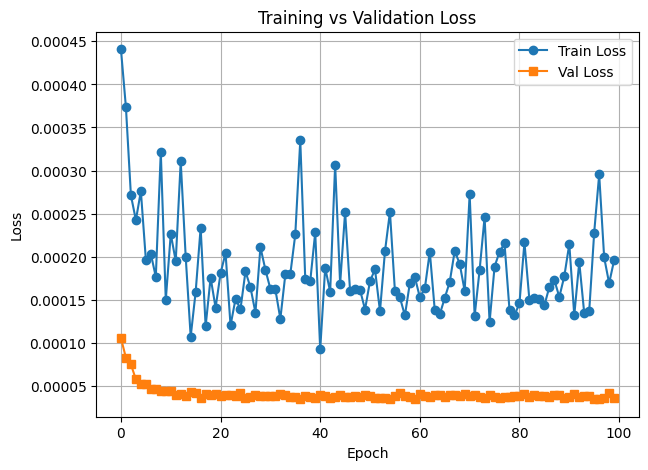

🔵 Confusion Matrix – TRAIN – Unsaved Best Model...


<Figure size 700x600 with 0 Axes>

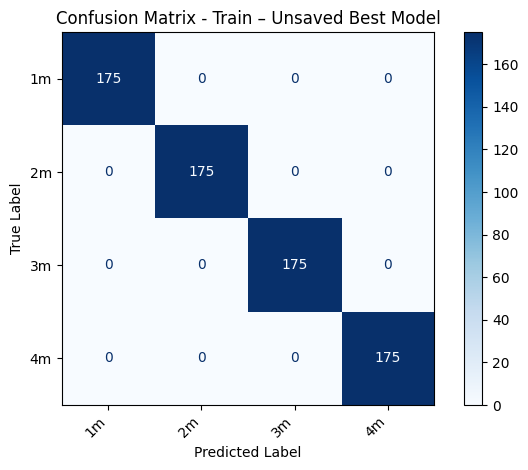

Train – Unsaved Best Model Accuracy: 100.00%

🟡 Confusion Matrix – VALIDATION – Unsaved Best Model...


<Figure size 700x600 with 0 Axes>

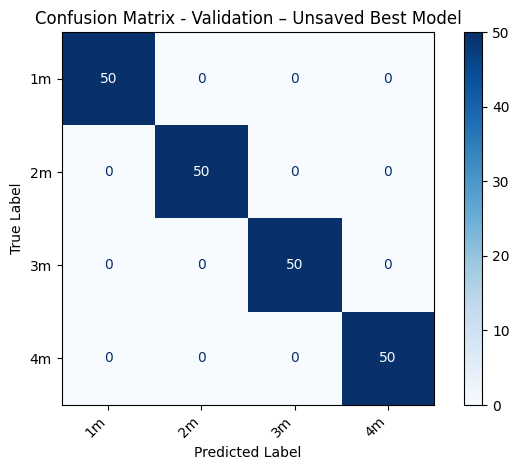

Validation – Unsaved Best Model Accuracy: 100.00%

🔵 Evaluating UNSAVED Best Model on TEST Set...


<Figure size 700x600 with 0 Axes>

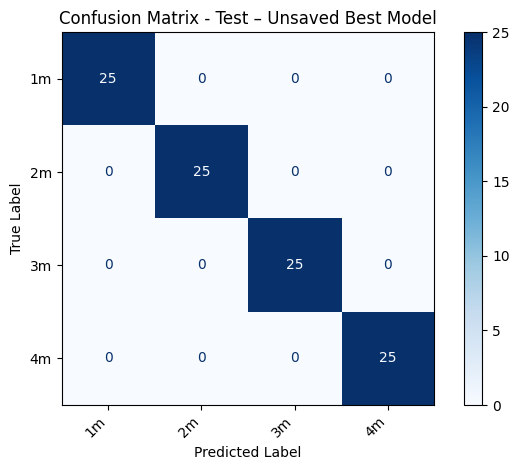

Test – Unsaved Best Model Accuracy: 100.00%

🟣 Evaluating .pth Model on Test Set...


<Figure size 700x600 with 0 Axes>

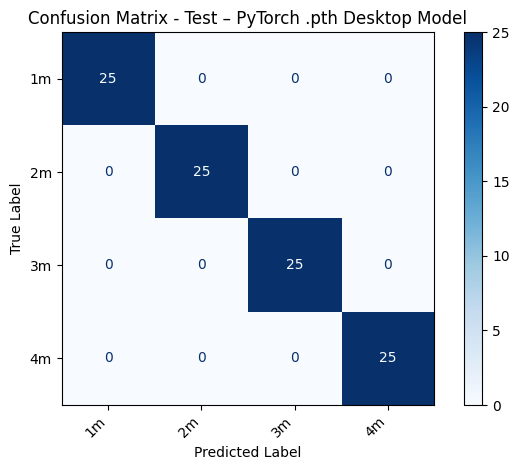

Test – PyTorch .pth Desktop Model Accuracy: 100.00%

📱 Evaluating TorchScript .pt Android Model on Test Set...


<Figure size 700x600 with 0 Axes>

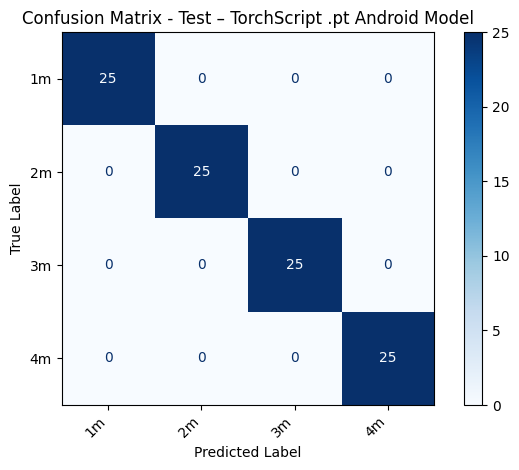

Test – TorchScript .pt Android Model Accuracy: 100.00%



In [11]:
# ============================================================
# Cell 2: Loss curves + Confusion matrices on TRAIN / VAL / TEST
#          for Unsaved Best Model + Weights-only (.pth) + TorchScript (.pt)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision.models import resnet18
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1) Plot Training vs Validation Loss
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='s', label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 2) Confusion Matrix Helper (works for nn.Module + TorchScript)
# ------------------------------------------------------------
def get_class_names_from_dataloader(dataloader, cm):
    ds = dataloader.dataset
    # Direct ImageFolder or similar
    if hasattr(ds, "classes"):
        return ds.classes
    # Subset(ImageFolder) or similar
    if hasattr(ds, "dataset") and hasattr(ds.dataset, "classes"):
        return ds.dataset.classes
    # Fallback: numeric labels
    return [str(i) for i in range(cm.shape[0])]

def plot_confusion_matrix_model(model, dataloader, split_name="Dataset"):
    model.eval()

    # TorchScript supports .to(), but add fallback
    try:
        model.to(device)
    except Exception:
        pass

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = confusion_matrix(all_labels, all_preds)
    class_names = get_class_names_from_dataloader(dataloader, cm)

    plt.figure(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d")

    plt.title(f"Confusion Matrix - {split_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.grid(False)
    plt.show()

    acc = (all_preds == all_labels).mean() * 100.0
    print(f"{split_name} Accuracy: {acc:.2f}%\n")

# ------------------------------------------------------------
# 3) Rebuild Python Model from WEIGHTS-ONLY .pth
# ------------------------------------------------------------
def build_resnet_from_state_dict(state_dict):
    num_classes = state_dict["fc.weight"].shape[0]
    m = resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    m.load_state_dict(state_dict)
    return m

# Load weights-only
weights_path = "UStar_Optical_Ranging_ResNet_18_Zhalgas.pth"
state_dict_weights = torch.load(weights_path, map_location="cpu")
model_weights = build_resnet_from_state_dict(state_dict_weights)

# ------------------------------------------------------------
# 4) Load TorchScript (.pt) model for Android
# ------------------------------------------------------------
pt_path = "UStar_Optical_Ranging_ResNet_18_Zhalgas.pt"
model_script = torch.jit.load(pt_path, map_location="cpu")

# ------------------------------------------------------------
# 5) Evaluate UNSAVED Best Model (TRAIN, VAL, TEST)
# ------------------------------------------------------------
model_unsaved = model  # from Cell 1 (already best weights, on CPU)

print("🔵 Confusion Matrix – TRAIN – Unsaved Best Model...")
plot_confusion_matrix_model(
    model_unsaved,
    train_loader,
    split_name="Train – Unsaved Best Model"
)

print("🟡 Confusion Matrix – VALIDATION – Unsaved Best Model...")
plot_confusion_matrix_model(
    model_unsaved,
    val_loader,
    split_name="Validation – Unsaved Best Model"
)

print("🔵 Evaluating UNSAVED Best Model on TEST Set...")
plot_confusion_matrix_model(
    model_unsaved,
    test_loader,
    split_name="Test – Unsaved Best Model"
)

# ------------------------------------------------------------
# 6) Evaluate WEIGHTS-ONLY .pth model (TEST)
# ------------------------------------------------------------
print("🟣 Evaluating .pth Model on Test Set...")
plot_confusion_matrix_model(
    model_weights,
    test_loader,
    split_name="Test – PyTorch .pth Desktop Model"
)

# ------------------------------------------------------------
# 7) Evaluate TorchScript .pt Android Model (TEST)
# ------------------------------------------------------------
print("📱 Evaluating TorchScript .pt Android Model on Test Set...")
plot_confusion_matrix_model(
    model_script,
    test_loader,
    split_name="Test – TorchScript .pt Android Model"
)

13. Download the model

In [12]:
from google.colab import files
files.download("UStar_Optical_Ranging_ResNet_18_Zhalgas.pt")
files.download("UStar_Optical_Ranging_ResNet_18_Zhalgas.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>